# Setup

In [18]:
# General packages
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import string
import re
import unicodedata
from pathlib import Path

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from nltk.corpus import wordnet

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

In [19]:
# output path
output_dir = Path("../outputs/visualizations/classification_tfidf")
output_dir.mkdir(parents=True, exist_ok=True)

In [20]:
# specify stopword resources
for resource in [
    "punkt",
    "stopwords",
    "wordnet",
    "averaged_perceptron_tagger"
]:
    nltk.download(resource, quiet=True)

In [21]:
# import data
aff = pd.read_csv("../data/raw/cleaned_job_affiliations.csv")

In [22]:
aff.info()

<class 'pandas.DataFrame'>
RangeIndex: 109485 entries, 0 to 109484
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   affiliate_id_18   109485 non-null  str  
 1   function          90572 non-null   str  
 2   title             51280 non-null   str  
 3   role              46778 non-null   str  
 4   management_level  70720 non-null   str  
 5   role_level        29230 non-null   str  
 6   role_imputed      96976 non-null   str  
dtypes: str(7)
memory usage: 5.8 MB


In [23]:
aff.head()

,affiliate_id_18,function,title,role,management_level,role_level,role_imputed
0,a0d3300000CSzeXAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN,Analyst Fellow
1,a0d3300000CSzjSAAT,General Management,NaN,Special Associate to the President,NaN,NaN,Special Associate to the President
2,a0d3300000CSzjUAAT,Data / Analytics / Research,NaN,Analyst Fellow,NaN,NaN,Analyst Fellow
3,a0d3300000CSzo6AAD,Academics (Teaching & Learning),NaN,Talented and Gifted Teacher,NaN,NaN,Talented and Gifted Teacher
4,a0d3300000CSzo7AAD,Academics (Teaching & Learning),NaN,Elementary Teacher,NaN,NaN,Elementary Teacher


# filter for applicable records

In [24]:
# filter for eligible records
has_role_mask = aff['role_imputed'].notna() & (aff['role_imputed'] != "")
has_function_mask = aff['function'].notna() & (aff['function'] != "")

func_aff = aff[has_role_mask & has_function_mask]

# text preprocessing

In [25]:
# prepearing wordnet lemmatizer
stop_words = set(stopwords.words("english"))
stop_words = set(stopwords.words("english")) - {"not", "no", "nor"}
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [26]:
# for cleaning/preping text 
def prep_text(text):
    # lowercase
    text = text.lower()

    # remove non-ASCII, digits, punctuation
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("utf-8")
    text = re.sub(r"\d+", "", text)
    text = text.translate(
        str.maketrans(string.punctuation, " " * len(string.punctuation))
    )
    text = re.sub(r"\s+", " ", text).strip()

    # tokenize
    tokens = word_tokenize(text)

    # POS tagging
    tagged_tokens = pos_tag(tokens)

    # lemmatize with POS awareness
    tokens = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]

    # remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    return tokens

# create a cleaned title_role column

In [27]:
# create a cleaned title_role column
func_aff['preped_role'] = func_aff['role_imputed'].apply(lambda x: ' '.join(prep_text(x)))

# encode categorical labels
le = LabelEncoder()
function_int = le.fit_transform(func_aff['function'])

## split data

In [28]:
# split data
X = func_aff['preped_role']
y = function_int

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    train_size=0.7, 
                                                    random_state=34, 
                                                    stratify=y)

In [29]:
# create Tf-IDF pipeline
tfidf_pipe = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
ngram_range=(1, 2),
            min_df=2, 
            max_df=0.9
        )
    ),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            random_state=33, 
            C = 5
        )
    )
])

In [30]:
# baseline model
tfidf_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [31]:
# check vocab size
vocab_size = len(tfidf_pipe.named_steps['tfidf'].vocabulary_)
print(f"{vocab_size} words in vocabulary")

12260 words in vocabulary


# Evaluation

In [32]:
# confusion matrix plot
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_name):
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm_norm,
        annot=True,
        fmt='.2f',
        cmap='Greens',
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    
    plt.savefig(
        output_dir / save_name,
        dpi=300,
        bbox_inches="tight"
        )
plt.show()
plt.close()

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      7977
           1       0.48      0.51      0.49      1156
           2       0.65      0.67      0.66      3085
           3       0.57      0.31      0.40       398
           4       0.64      0.56      0.59       878
           5       0.54      0.67      0.60      2570
           6       0.65      0.48      0.55       659
           7       0.77      0.65      0.70       434
           8       0.55      0.56      0.56      1523
           9       0.45      0.44      0.45      1642
          10       0.27      0.16      0.20       580
          11       0.49      0.37      0.42       633
          12       0.47      0.54      0.50      2604
          13       0.58      0.42      0.49      1017
          14       0.34      0.16      0.21       852
          15       0.52      0.43      0.47       602

    accuracy                           0.64     26610
   macro avg       0.55   

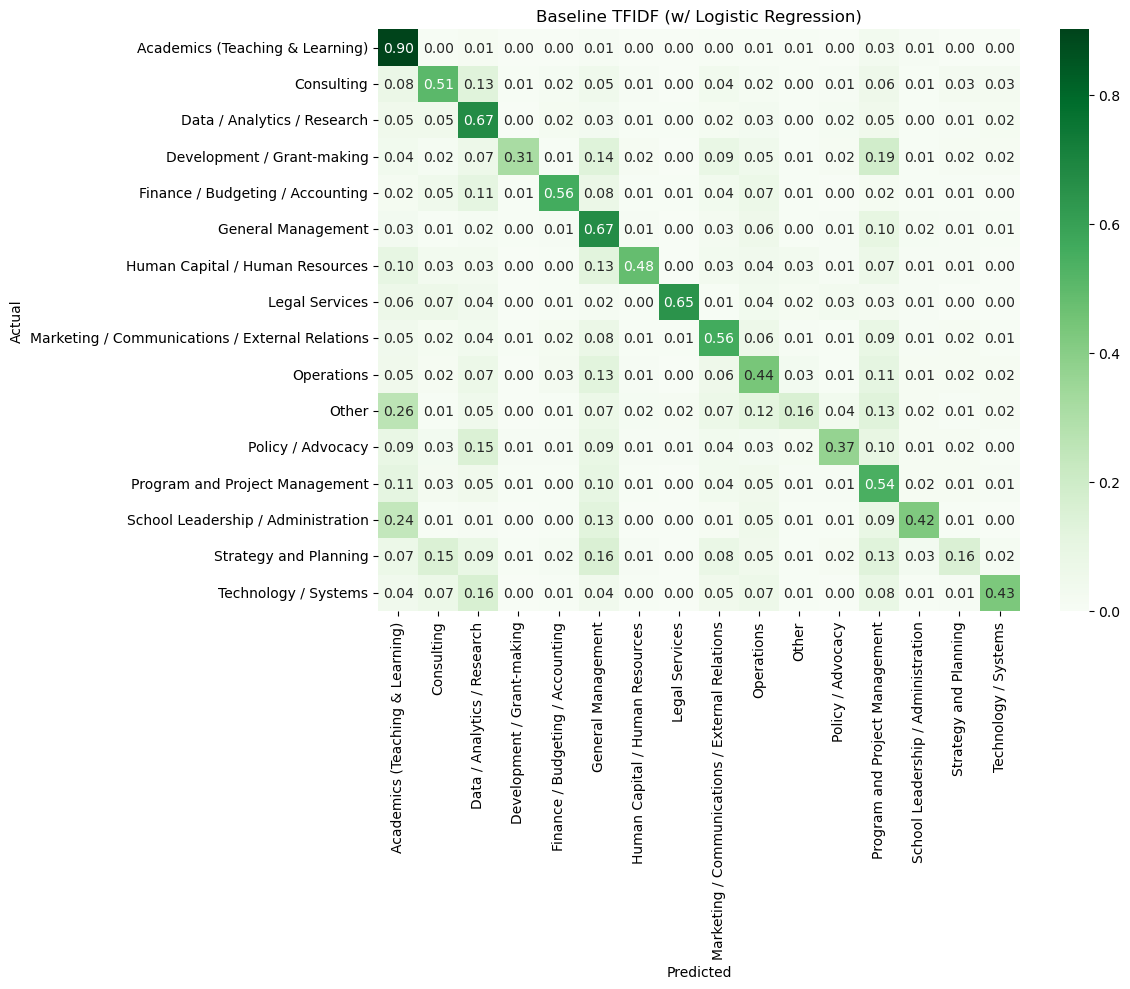

In [33]:
# baseline performance
y_pred_baseline = tfidf_pipe.predict(X_test)
baseline_classes = le.classes_

# precision, recall, support, and f1 score
print(classification_report(y_test, y_pred_baseline))

print(f"Macro F1: {f1_score(y_test, y_pred_baseline, average='macro'):.4f}")

# confusion matrix
plot_confusion_matrix(y_test, 
                      y_pred_baseline, 
                      baseline_classes, 
                      "Baseline TFIDF (w/ Logistic Regression)", 
                      "baseline_tfidf.png")

# Tuning

In [34]:
# create parameter grid for grid search
param_grid = {
    'tfidf__ngram_range': [(1,2), (1,3), (1,4)],
    'clf__C' : [0.1, 0.5, 1, 10],
}

In [35]:
# create grid search
gs_tfidf = GridSearchCV(tfidf_pipe, 
                        param_grid, 
                        cv=5, 
                        scoring = ['f1_macro', 'precision_macro', 'recall_macro'], 
                        refit = 'f1_macro', 
                        n_jobs = -2)

gs_tfidf.fit(X_train, y_train)


/opt/homebrew/Caskroom/miniconda/base/envs/venv_folio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/venv_folio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/homebrew/Caskroom/miniconda/base/envs/venv_folio/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=33))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'clf__C': [0.1, 0.5, ...], 'tfidf__ngram_range': [(1, ...), (1, ...), ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['f1_macro', 'precision_macro', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1_macro'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candid

In [36]:
#  check best parameters
print(gs_tfidf.best_params_)
print(gs_tfidf.best_score_)

{'clf__C': 1, 'tfidf__ngram_range': (1, 3)}
0.5093565325939889


In [37]:
gs_results = pd.DataFrame(gs_tfidf.cv_results_)

In [38]:
# The most useful columns
display(gs_results[[
    'rank_test_f1_macro',
    'params',
    'mean_test_f1_macro',
    'std_test_f1_macro',
    'mean_test_precision_macro',
    'mean_test_recall_macro'
    ]].sort_values('rank_test_f1_macro'))

,rank_test_f1_macro,params,mean_test_f1_macro,std_test_f1_macro,mean_test_precision_macro,mean_test_recall_macro
7,1,"{'clf__C': 1, 'tfidf__ngram_range': (1, 3)}",0.509357,0.002926,0.575284,0.479036
6,2,"{'clf__C': 1, 'tfidf__ngram_range': (1, 2)}",0.509231,0.002559,0.574983,0.478962
8,3,"{'clf__C': 1, 'tfidf__ngram_range': (1, 4)}",0.508857,0.002987,0.574052,0.478790
3,4,"{'clf__C': 0.5, 'tfidf__ngram_range': (1, 2)}",0.503344,0.001849,0.586568,0.468917
5,5,"{'clf__C': 0.5, 'tfidf__ngram_range': (1, 4)}",0.502348,0.002449,0.586470,0.467951
4,6,"{'clf__C': 0.5, 'tfidf__ngram_range': (1, 3)}",0.502206,0.002269,0.586581,0.467696
9,7,"{'clf__C': 10, 'tfidf__ngram_range': (1, 2)}",0.493369,0.003732,0.524798,0.475272
10,8,"{'clf__C': 10, 'tfidf__ngram_range': (1, 3)}",0.492619,0.002786,0.522932,0.474664
11,9,"{'clf__C': 10, 'tfidf__ngram_range': (1, 4)}",0.492239,0.002518,0.521589,0.474852
0,10,"{'clf__C': 0.1, 'tfidf__ngram_range': (1, 2)}",0.445026,0.002829,0.596929,0.401722


              precision    recall  f1-score   support

           0       0.81      0.92      0.86      7977
           1       0.48      0.48      0.48      1156
           2       0.66      0.70      0.68      3085
           3       0.62      0.29      0.40       398
           4       0.68      0.56      0.61       878
           5       0.54      0.69      0.61      2570
           6       0.68      0.46      0.55       659
           7       0.84      0.63      0.72       434
           8       0.56      0.58      0.57      1523
           9       0.47      0.46      0.47      1642
          10       0.37      0.13      0.19       580
          11       0.56      0.34      0.43       633
          12       0.48      0.55      0.52      2604
          13       0.63      0.42      0.51      1017
          14       0.40      0.16      0.23       852
          15       0.55      0.43      0.48       602

    accuracy                           0.65     26610
   macro avg       0.58   

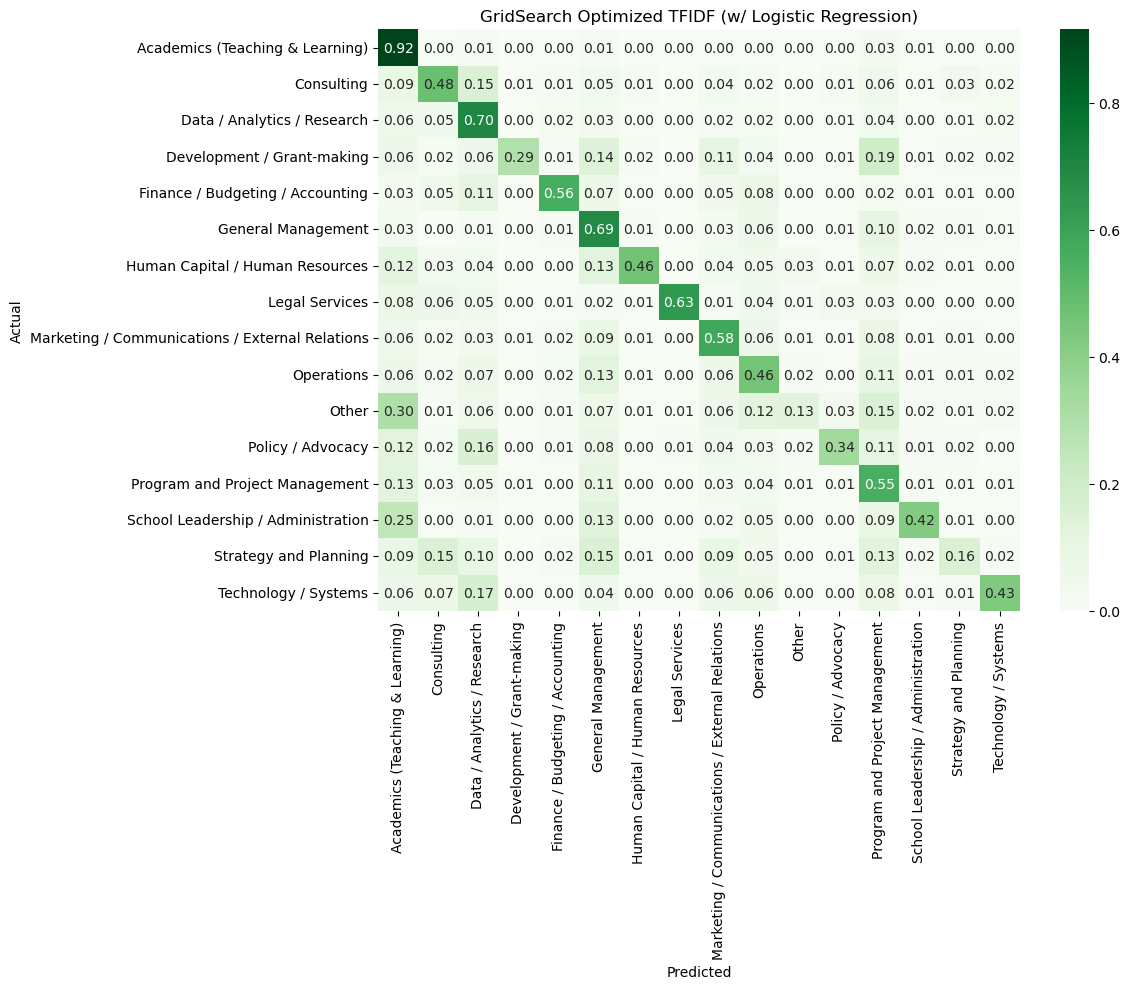

In [39]:
# grid search best model performance
y_pred_gs = gs_tfidf.predict(X_test)
gs_classes = le.classes_

print(classification_report(y_test, y_pred_gs))
print(f"Macro F1: {f1_score(y_test, y_pred_gs, average='macro'):.4f}")

plot_confusion_matrix(y_test, 
                      y_pred_gs, 
                      gs_classes, 
                      "GridSearch Optimized TFIDF (w/ Logistic Regression)",
                      "optimized_tfidf.png")

## Tune threshold

In [40]:
# best model data
best_pipe = gs_tfidf.best_estimator_
classes = best_pipe.named_steps["clf"].classes_

# best model probablity and labels
probs = best_pipe.predict_proba(X_test)
max_probs = probs.max(axis=1)
pred_labels = classes[np.argmax(probs, axis=1)]

In [41]:
# testing label thresholds between 0.1 and 0.85 at 0.05 intervals
thresholds = np.arange(0.10, 0.85, 0.05)
thresholds_results = []

for t in thresholds:
    # identify records above threshold
    accepted = max_probs >= t

    # stop early if no records above threshold
    if accepted.sum() == 0:
        thresholds_results.append({
            "threshold": t,
            "coverage": 0,
            "macro_f1": 0
        })
        continue

    # use f1 to gauge performance at the threshold
    y_true_sel = np.array(y_test)[accepted]
    y_pred_sel = pred_labels[accepted]

    f1_macro = f1_score(
        y_true_sel,
        y_pred_sel,
        average='macro',
        zero_division=0
    )

    # measure prop of records are labeled
    coverage = accepted.mean()

    # record
    thresholds_results.append({
        "threshold": round(t, 2),
        "coverage": round(coverage, 4),
        "macro_f1": round(f1_macro, 4)
    })

thresholds_results_df = pd.DataFrame(thresholds_results)

In [42]:
display(thresholds_results_df)

,threshold,coverage,macro_f1
0,0.10,1.0000,0.5194
1,0.15,0.9937,0.5216
2,0.20,0.9605,0.5336
3,0.25,0.8988,0.5555
4,0.30,0.8394,0.5747
5,0.35,0.7726,0.5966
6,0.40,0.7167,0.6123
7,0.45,0.6569,0.6327
8,0.50,0.6056,0.6447
9,0.55,0.5592,0.6568


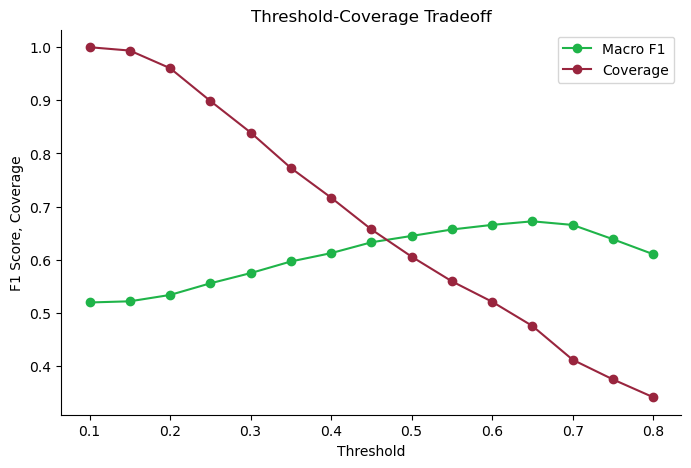

In [43]:
# visualize the tradeoff between performance and coverate at different thresholds
plt.figure(figsize=(8,5))

# F1 Scores
plt.plot(thresholds_results_df['threshold'], 
         thresholds_results_df['macro_f1'], 
         marker='o', 
         color = '#1fb449', 
         label='Macro F1')

# coverage
plt.plot(thresholds_results_df['threshold'], 
         thresholds_results_df['coverage'], 
         marker='o', 
         color = '#99253E',
         label='Coverage')

plt.xlabel("Threshold")
plt.ylabel("F1 Score, Coverage")
plt.title("Threshold-Coverage Tradeoff")
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig(
    output_dir / "aggregated_threshold_f1_coverage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()

### Class specific thresholds

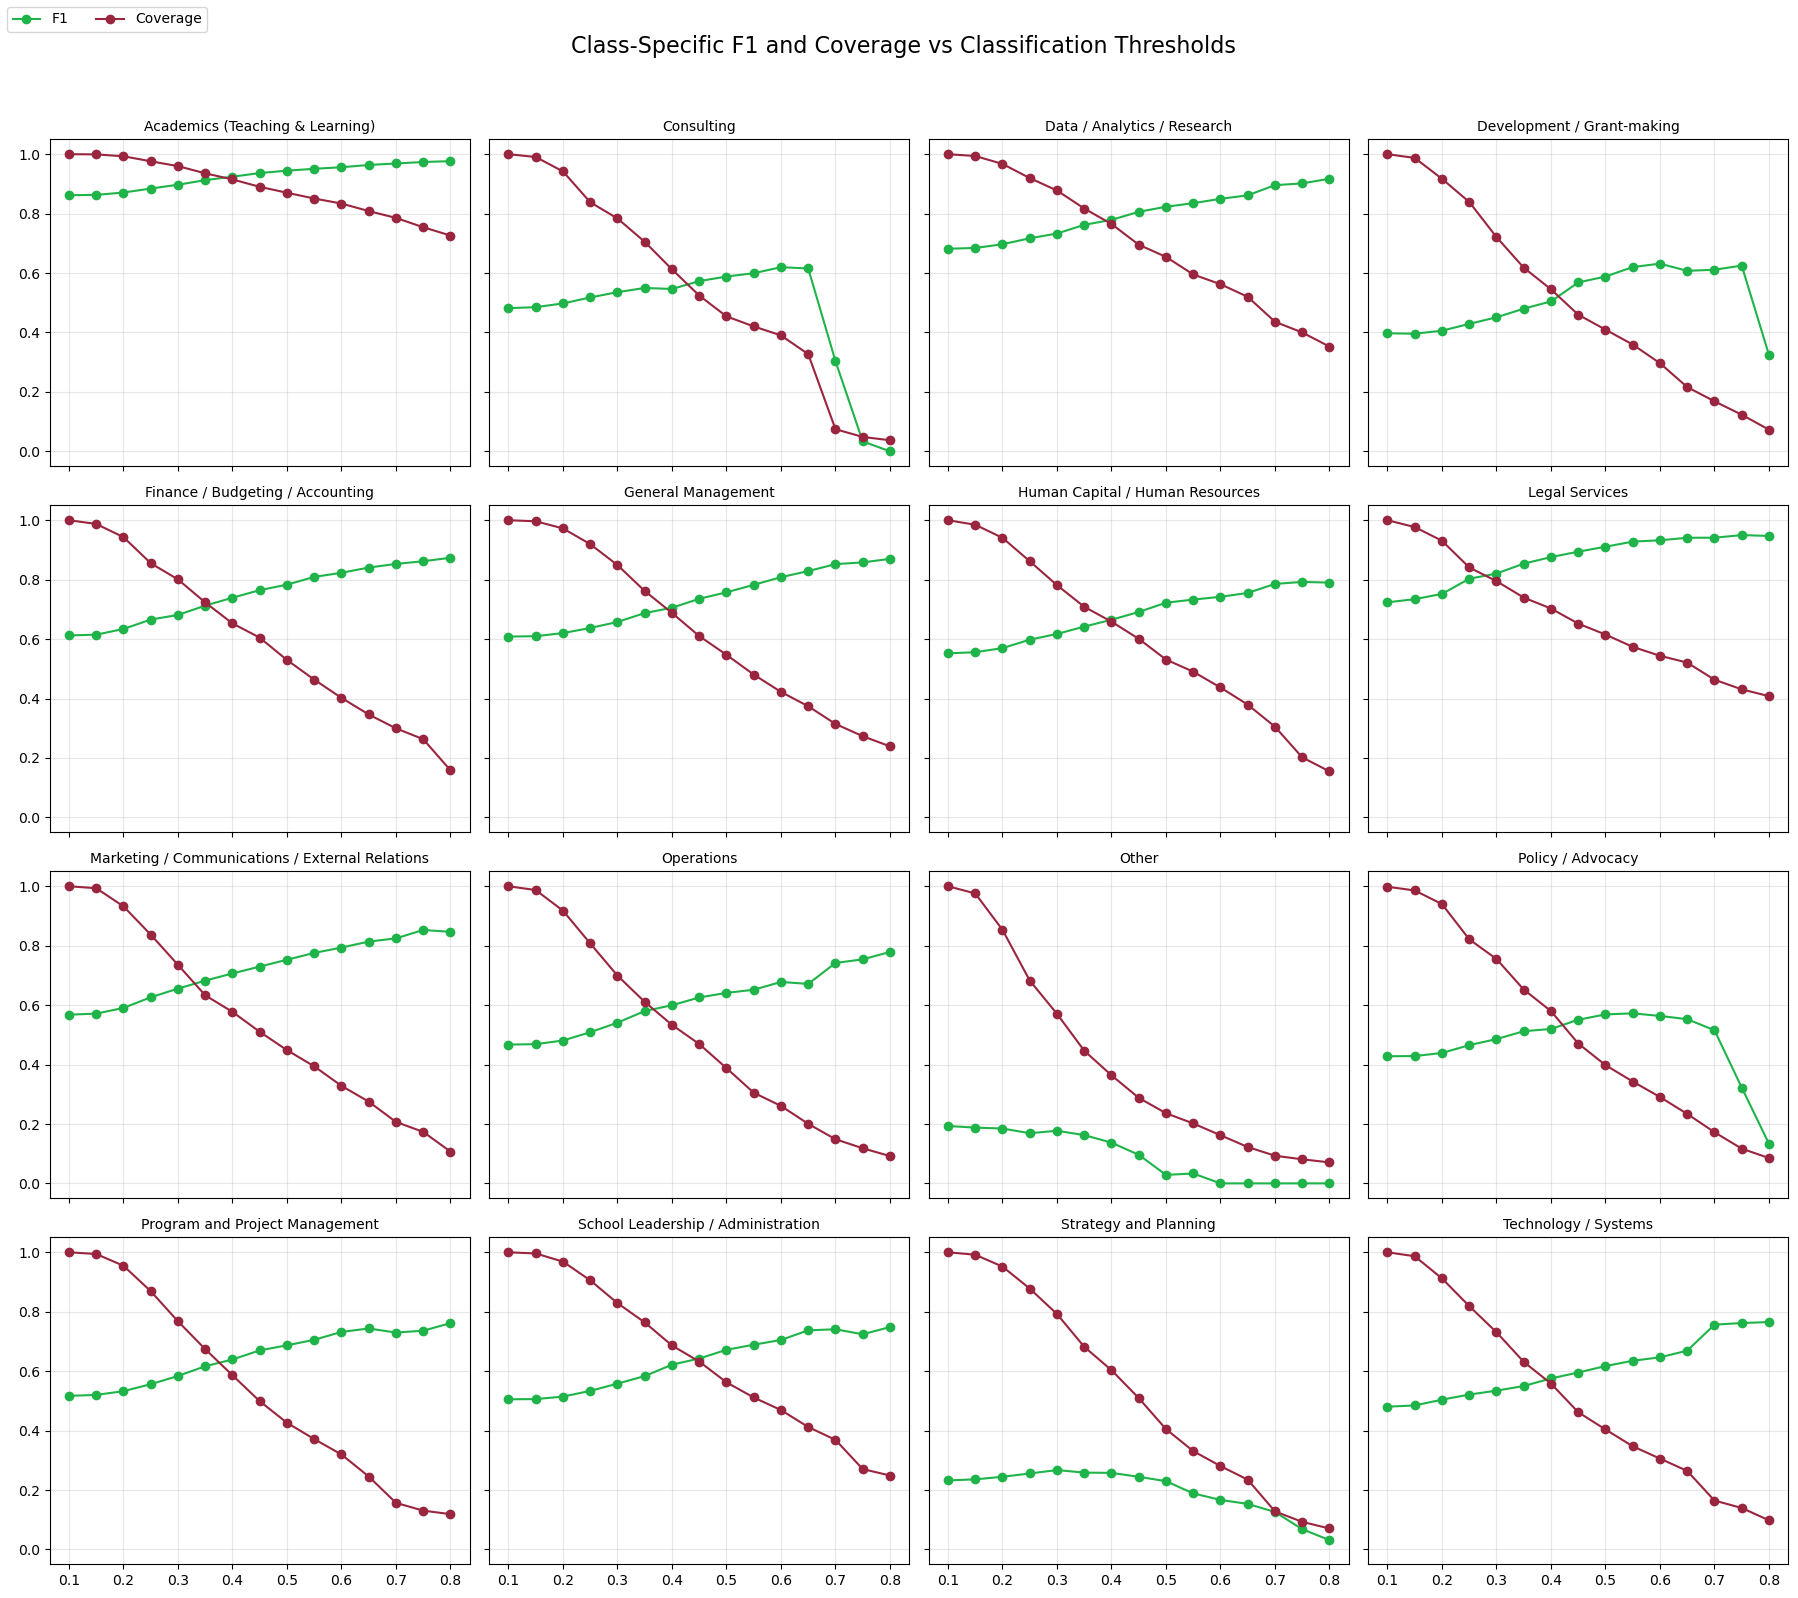

In [44]:
classes = le.classes_

# create a 4x4 figure for 16 classes
fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(18, 16),
    sharex=True,
    sharey=True
)
axes = axes.flatten()

# loop through each class and create a distinct threshold vs coverage, F1 score vis
for i, class_name in enumerate(classes):
    ax = axes[i]
    class_code = le.transform([class_name])[0]
    results = []

    for t in thresholds:
        accepted = max_probs >= t
        
        # for computing perf metrics (actual vs predicted)
        y_true_bin = (np.array(y_test) == class_code)
        y_pred_bin = (pred_labels == class_code)

        # only run if there are records with a predicted label probability greater than threshold
        if accepted.sum() > 0:
            f1 = f1_score(
                # compare the actual and predicted records above the threshold for f1 score
                y_true_bin[accepted],
                y_pred_bin[accepted],
                zero_division=0
            )

            # class specific coverage
            class_mask = (y_test == class_code)
            class_coverage = (accepted[class_mask].mean() if class_mask.sum() > 0 else 0)

        else:
            f1 = 0
            class_coverage = 0

        results.append({
            "threshold": t,
            "f1": f1,
            "coverage": class_coverage
        })

    # graph f1 score
    ax.plot(
        thresholds,
        [r['f1'] for r in results],
        marker='o',
        color = '#1fb449',
        label='F1'
    )
    # graph coverage
    ax.plot(
        thresholds,
        [r['coverage'] for r in results],
        marker='o',
        color = '#99253E',
        label='Coverage'
    )

    ax.set_title(class_name, fontsize=10)
    ax.grid(alpha=.3)

# one legend for the entire figure
handles, labels = axes[0].get_legend_handles_labels()

# design
fig.legend(
    handles,
    labels,
    loc='upper left',
    ncol=2
)

fig.suptitle(
    "Class-Specific F1 and Coverage vs Classification Thresholds",
    fontsize=16
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(
    output_dir / "class_threshold_f1_coverage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
plt.close()